# SAM2-Video



-----
- Conda env : [cv_playgrounds](../../README.md#setup-a-conda-environment)
-----


### Reference:
- ***Paper***
    - [SAM 2: Segment Anything in Images and Videos](https://arxiv.org/abs/2408.00714)
- ***Colab***
    - https://colab.research.google.com/drive/1Z0NGLE7p8qnc9UpuI8KBETHd2xBbOEhv?usp=sharing#scrollTo=17737191-d62b-4611-b2c6-6d0418a9ab74
- ***Blogs***
    - [Introducing Meta Segment Anything Model 2 (SAM 2)](https://ai.meta.com/sam2/)
    - [SAM2 Video](https://huggingface.co/docs/transformers/main/model_doc/sam2_video)

## Device Setup

In [1]:
import torch

if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
    !nvidia-smi
else:
    device = "cpu"

print(f"Available device : {device}")

Tue Oct  7 12:10:57 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2080 Ti     On  |   00000000:01:00.0  On |                  N/A |
| 38%   44C    P8             22W /  250W |     533MiB /  11264MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
from transformers import (
    Sam2Config,
    Sam2ImageProcessorFast,
    Sam2Model,
    Sam2VideoModel,
    Sam2VideoProcessor,
    Sam2VideoVideoProcessor,
)

image_processor = Sam2ImageProcessorFast()
video_processor = Sam2VideoVideoProcessor()
processor = Sam2VideoProcessor(image_processor=image_processor, video_processor=video_processor)

In [4]:
sam2model = Sam2VideoModel.from_pretrained("danelcsb/sam2.1_hiera_tiny").to(device)

In [ ]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

In [6]:
from transformers.video_utils import load_video
video_url = "https://huggingface.co/datasets/hf-internal-testing/sam2-fixtures/resolve/main/bedroom.mp4"
video_frames, _ = load_video(video_url)

In [ ]:
from IPython.display import Video
Video(video_url, width=480, height=270)

In [7]:
video_frames[0].shape


(540, 960, 3)

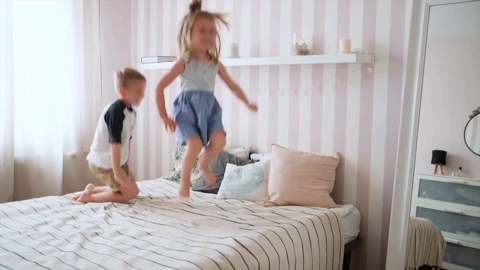

In [9]:
img_1 = Image.fromarray(video_frames[0])
img_1.resize((480, 270))

In [10]:
inference_session = processor.init_video_session(video=video_frames, inference_device=device)
print("length : ", inference_session.num_frames)

length :  200


### Example 1: Segment & track one object

In [11]:
inference_session.reset_inference_session()

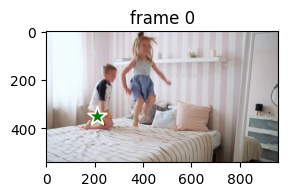

In [17]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = [1]  # give a unique id to each object we interact with (it can be any integers)
points = np.array([[[[210, 350]]]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([[[1]]], np.int32)

# Let's add a positive click at (x, y) = (210, 350) to get started
processor.process_new_points_or_boxes_for_video_frame(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_points=points,
    input_labels=labels
)

Sam2VideoSegmentationOutput = sam2model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = Sam2VideoSegmentationOutput.pred_masks
video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
frame_idx = Sam2VideoSegmentationOutput.frame_idx

# show the results on the current (interacted) frame
plt.figure(figsize=(3, 2))
plt.title(f"frame {ann_frame_idx}")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.fromarray(video_frames[ann_frame_idx]))
show_points(points, labels, plt.gca())
show_mask((video_res_masks[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=inference_session.obj_ids[0])

### Step 2: Add a second click to refine the prediction

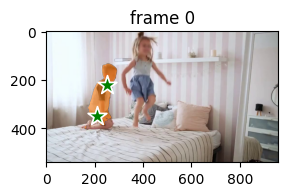

In [18]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = [1]  # give a unique id to each object we interact with (it can be any integers)

# Let's add a 2nd positive click at (x, y) = (250, 220) to refine the mask
# sending all clicks (and their labels) to `add_new_points_or_box`
points = np.array([[[[210, 350], [250, 220]]]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([[[1, 1]]], np.int32)

processor.process_new_points_or_boxes_for_video_frame(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_points=points,
    input_labels=labels
)

Sam2VideoSegmentationOutput = sam2model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = Sam2VideoSegmentationOutput.pred_masks
video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
frame_idx = Sam2VideoSegmentationOutput.frame_idx

# show the results on the current (interacted) frame
plt.figure(figsize=(3, 2))
plt.title(f"frame {ann_frame_idx}")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.fromarray(video_frames[ann_frame_idx]))
show_points(points, labels, plt.gca())
show_mask((video_res_masks[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=inference_session.obj_ids[0])

### Step 3: Propagate the prompts to get the masklet across the video

propagate in video:   0%|          | 0/200 [00:00<?, ?it/s]

propagate in video: 100%|██████████| 200/200 [00:29<00:00,  6.73it/s]


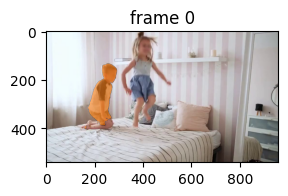

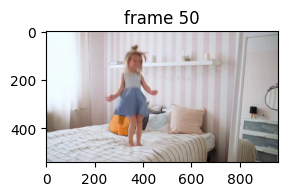

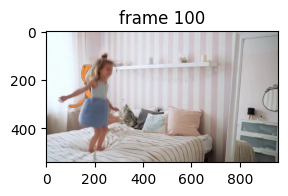

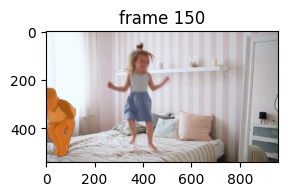

In [19]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for sam2_video_output in sam2model.propagate_in_video_iterator(inference_session):
    frame_idx = sam2_video_output.frame_idx
    video_res_masks = sam2_video_output.pred_masks
    video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
    obj_ids = inference_session.obj_ids
    video_segments[frame_idx] = {
        out_obj_id: (video_res_masks[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 50
plt.close("all")
for out_frame_idx in range(0, len(video_frames), vis_frame_stride):
    plt.figure(figsize=(3, 2))
    plt.title(f"frame {out_frame_idx}")
    # plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    plt.imshow(Image.fromarray(video_frames[out_frame_idx]))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

### Step 4: Add new prompts to further refine the masklet

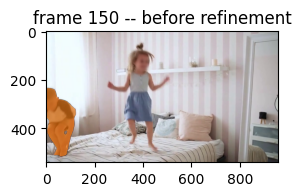

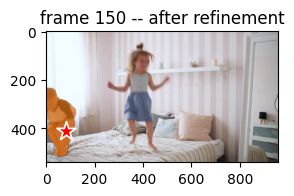

In [21]:
ann_frame_idx = 150  # further refine some details on this frame
ann_obj_id = [1]  # give a unique id to the object we interact with (it can be any integers)

# show the segment before further refinement
plt.figure(figsize=(3, 2))
plt.title(f"frame {ann_frame_idx} -- before refinement")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.fromarray(video_frames[ann_frame_idx]))
show_mask(video_segments[ann_frame_idx][ann_obj_id[0]], plt.gca(), obj_id=ann_obj_id[0])

# Let's add a negative click on this frame at (x, y) = (82, 415) to refine the segment
points = np.array([[[[82, 410]]]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([[[0]]], np.int32)

processor.process_new_points_or_boxes_for_video_frame(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_points=points,
    input_labels=labels
)

Sam2VideoSegmentationOutput = sam2model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = Sam2VideoSegmentationOutput.pred_masks
video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
frame_idx = Sam2VideoSegmentationOutput.frame_idx

# show the results on the current (interacted) frame
plt.figure(figsize=(3, 2))
plt.title(f"frame {ann_frame_idx} -- after refinement")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.fromarray(video_frames[ann_frame_idx]))
show_points(points, labels, plt.gca())
show_mask((video_res_masks[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=inference_session.obj_ids[0])

### Step 5: Propagate the prompts (again) to get the masklet across the video

propagate in video:   0%|          | 0/200 [00:00<?, ?it/s]

propagate in video: 100%|██████████| 200/200 [00:29<00:00,  6.69it/s]


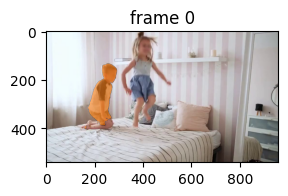

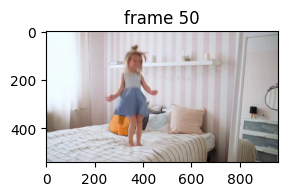

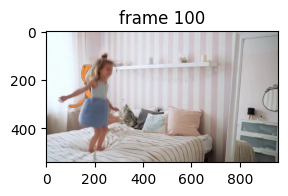

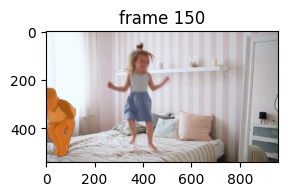

In [22]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for sam2_video_output in sam2model.propagate_in_video_iterator(inference_session):
    frame_idx = sam2_video_output.frame_idx
    video_res_masks = sam2_video_output.pred_masks
    video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
    obj_ids = inference_session.obj_ids
    video_segments[frame_idx] = {
        out_obj_id: (video_res_masks[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 50
plt.close("all")
for out_frame_idx in range(0, len(video_frames), vis_frame_stride):
    plt.figure(figsize=(3, 2))
    plt.title(f"frame {out_frame_idx}")
    # plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    plt.imshow(Image.fromarray(video_frames[out_frame_idx]))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

## Example 2: Segment an object using box prompt

In [23]:
inference_session.reset_inference_session()

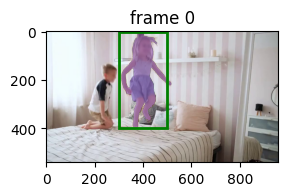

In [24]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = [4]  # give a unique id to each object we interact with (it can be any integers)

# Let's add a box at (x_min, y_min, x_max, y_max) = (300, 0, 500, 400) to get started
box = np.array([[[300, 0, 500, 400]]], dtype=np.float32)

processor.process_new_points_or_boxes_for_video_frame(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_points=None,
    input_labels=None,
    input_boxes=box
)

Sam2VideoSegmentationOutput = sam2model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = Sam2VideoSegmentationOutput.pred_masks
video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
frame_idx = Sam2VideoSegmentationOutput.frame_idx

# show the results on the current (interacted) frame
plt.figure(figsize=(3, 2))
plt.title(f"frame {ann_frame_idx}")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.fromarray(video_frames[ann_frame_idx]))
show_box(box[0][0], plt.gca())
show_mask((video_res_masks[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=inference_session.obj_ids[0])

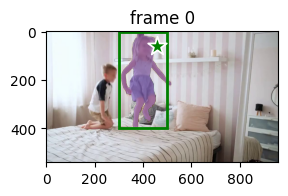

In [25]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = [4]  # give a unique id to each object we interact with (it can be any integers)

# Let's add a positive click at (x, y) = (460, 60) to refine the mask
points = np.array([[[[460, 60]]]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([[[1]]], np.int32)
# note that we also need to send the original box input along with
# the new refinement click together into `add_new_points_or_box`
box = np.array([[[300, 0, 500, 400]]], dtype=np.float32)

processor.process_new_points_or_boxes_for_video_frame(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_points=points,
    input_labels=labels,
    input_boxes=box
)

Sam2VideoSegmentationOutput = sam2model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = Sam2VideoSegmentationOutput.pred_masks
video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
frame_idx = Sam2VideoSegmentationOutput.frame_idx

# show the results on the current (interacted) frame
plt.figure(figsize=(3, 2))
plt.title(f"frame {ann_frame_idx}")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.fromarray(video_frames[ann_frame_idx]))
show_box(box[0][0], plt.gca())
show_points(points, labels, plt.gca())
show_mask((video_res_masks[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=inference_session.obj_ids[0])

propagate in video: 100%|██████████| 200/200 [00:30<00:00,  6.54it/s]


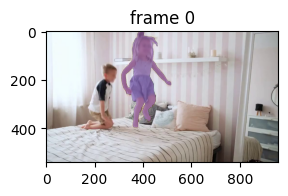

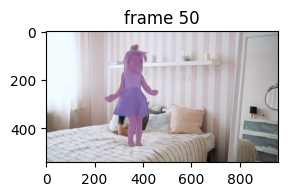

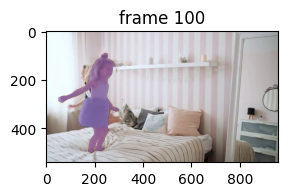

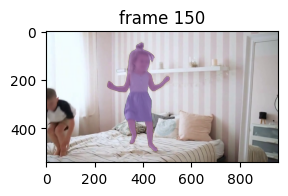

In [26]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for sam2_video_output in sam2model.propagate_in_video_iterator(inference_session):
    frame_idx = sam2_video_output.frame_idx
    video_res_masks = sam2_video_output.pred_masks
    video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
    obj_ids = inference_session.obj_ids
    video_segments[frame_idx] = {
        out_obj_id: (video_res_masks[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 50
plt.close("all")
for out_frame_idx in range(0, len(video_frames), vis_frame_stride):
    plt.figure(figsize=(3, 2))
    plt.title(f"frame {out_frame_idx}")
    # plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    plt.imshow(Image.fromarray(video_frames[out_frame_idx]))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

### Example 3: Segment multiple objects simultaneously

In [27]:
inference_session.reset_inference_session()

Step 1: Add two objects on a frame

In [28]:
prompts = {}  # hold all the clicks we add for visualization

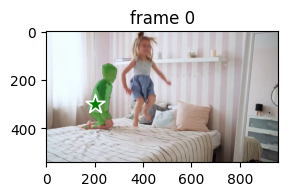

In [29]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = [2]  # give a unique id to each object we interact with (it can be any integers)

# Let's add a positive click at (x, y) = (200, 300) to get started on the first object
points = np.array([[[[200, 300]]]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([[[1]]], np.int32)
prompts[ann_obj_id[0]] = points, labels

processor.process_new_points_or_boxes_for_video_frame(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_points=points,
    input_labels=labels
)

Sam2VideoSegmentationOutput = sam2model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = Sam2VideoSegmentationOutput.pred_masks
video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
frame_idx = Sam2VideoSegmentationOutput.frame_idx

# show the results on the current (interacted) frame
plt.figure(figsize=(3, 2))
plt.title(f"frame {ann_frame_idx}")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.fromarray(video_frames[ann_frame_idx]))
show_points(points, labels, plt.gca())
show_mask((video_res_masks[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=inference_session.obj_ids[0])

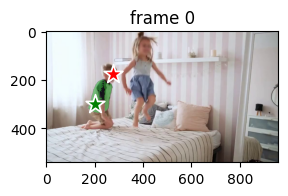

In [30]:
# add the first object
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = [2]  # give a unique id to each object we interact with (it can be any integers)

# Let's add a 2nd negative click at (x, y) = (275, 175) to refine the first object
# sending all clicks (and their labels) to `add_new_points_or_box`
points = np.array([[[[200, 300], [275, 175]]]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([[[1, 0]]], np.int32)
prompts[ann_obj_id[0]] = points, labels

processor.process_new_points_or_boxes_for_video_frame(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_points=points,
    input_labels=labels
)

Sam2VideoSegmentationOutput = sam2model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = Sam2VideoSegmentationOutput.pred_masks
video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
frame_idx = Sam2VideoSegmentationOutput.frame_idx

# show the results on the current (interacted) frame
plt.figure(figsize=(3, 2))
plt.title(f"frame {ann_frame_idx}")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.fromarray(video_frames[ann_frame_idx]))
show_points(points, labels, plt.gca())
show_mask((video_res_masks[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=inference_session.obj_ids[0])

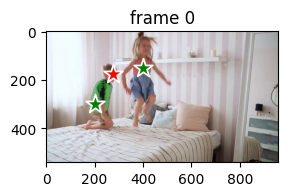

In [31]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = [3]  # give a unique id to each object we interact with (it can be any integers)

# Let's now move on to the second object we want to track (giving it object id `3`)
# with a positive click at (x, y) = (400, 150)
points = np.array([[[[400, 150]]]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([[[1]]], np.int32)
prompts[ann_obj_id[0]] = points, labels

processor.process_new_points_or_boxes_for_video_frame(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
    obj_ids=ann_obj_id,
    input_points=points,
    input_labels=labels
)

Sam2VideoSegmentationOutput = sam2model(
    inference_session=inference_session,
    frame_idx=ann_frame_idx,
)
video_res_masks = Sam2VideoSegmentationOutput.pred_masks
video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
frame_idx = Sam2VideoSegmentationOutput.frame_idx

# show the results on the current (interacted) frame
plt.figure(figsize=(3, 2))
plt.title(f"frame {ann_frame_idx}")
# plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
plt.imshow(Image.fromarray(video_frames[ann_frame_idx]))
for i, out_obj_id in enumerate(inference_session.obj_ids):
    show_points(*prompts[out_obj_id], plt.gca())
    show_mask((video_res_masks[0][i] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_id)

propagate in video:   0%|          | 0/200 [00:00<?, ?it/s]

propagate in video: 100%|██████████| 200/200 [00:49<00:00,  4.01it/s]


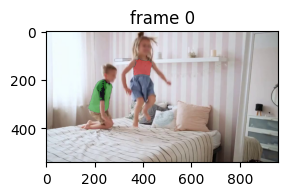

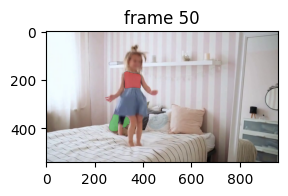

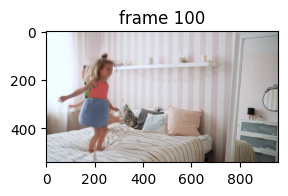

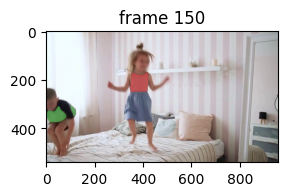

In [32]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for sam2_video_output in sam2model.propagate_in_video_iterator(inference_session):
    frame_idx = sam2_video_output.frame_idx
    video_res_masks = sam2_video_output.pred_masks
    video_res_masks = processor.post_process_masks([video_res_masks], [[inference_session.video_height, inference_session.video_width]])
    obj_ids = inference_session.obj_ids
    video_segments[frame_idx] = {
        out_obj_id: (video_res_masks[0][i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(obj_ids)
    }

# render the segmentation results every few frames
vis_frame_stride = 50
plt.close("all")
for out_frame_idx in range(0, len(video_frames), vis_frame_stride):
    plt.figure(figsize=(3, 2))
    plt.title(f"frame {out_frame_idx}")
    # plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    plt.imshow(Image.fromarray(video_frames[out_frame_idx]))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

In [33]:
video_res_masks[0].shape

torch.Size([2, 1, 540, 960])